In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb
from xgboost import XGBClassifier
import duckdb # for me to use sql even though it is not necessary with the way the datasets are given

In [61]:
#sklearn packages
import sklearn as sk
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score #modelperformance()
from sklearn.ensemble import RandomForestClassifier

In [3]:
#test cell

## Data Definition

I am asked by Northern Lights Air (NLA) to run an analysis on their loyalty program. NLA ran a promotional campaign from Februrary 2018 (2018-02-01) until April 2018 (2018-04-31). NLA wants to improve their loyalty program, hence they want to know:
- What impact did the campaign have on the loyalty memberships? (Enrollment, Cancellation, Points redeemed etc.)
- What impact did the campaign have on booked flights? (in the summer, in general etc.)
- What impact did it have on customer churning?
- Was the campaign more successful towards certain demographics? (Gender, Education, Marital Status etc.)

## Exploratory Analysis

I will use SQL (for fun) to explore the data. 

**392936** total data entries index starting at 0

### Calendar 
This is a dataset that gives me everyday from 2012-01-01 (January 1, 2012) until 2018-12-31 (December 31, 2018). It gives me:
- Start of Year: first date of the year
- Start of Quarter: first date of the quarter it's in (Jan 1, Apr 1, Jul 1, Oct 1)
- Start of Month: first date of the month it's in

### Customer Flights Activity 
- Loyalty Number: **16737** unique members based on loyalty numbers
- Year
- Month
- Total Flights: Do not have to be loyalty member to fly
- Distance
- Points Accumulated
- Points Redeemed
- Dollar Cost Points Redeemed (CAD)

### Loyalty Program 
- Loyalty Number: **16737** unique members based on loyalty numbers
- Country: Canada (constant)
- Province
- City
- Postal Code
- Gender
- Education
- Salary (CAD): Contains NULL and negatives
- Marital Status
- Loyalty Card
- CLV
- Enrollment Type
- Enrollment Year
- Enrollment Month
- Cancellation Year: Contains NULL
- Cancellation Month: Contains NULL

### New Column Ideas
- tenure (months): lengths a loyalty number has their membership. Uses latest date in calendar.csv if they have not cancelled
- total flights: total number of flights flown per loyalty number
- total distance: total distance flown per loyalty number
- total points: total points accumulated per loyalty number
- total redeemed points: total points redeemed per loyalty number
- percentage redeemed: percentage of points redeemed (total redeemed points divided by total points. If no points accumulated then 0)
- enrollment date: combine enrollment year and month
- cancellation date: combine cancellation year and month
- salary missing: whether a salary entry is null (1 if yes, 0 if no)
- cancelled: whether or not the membership was cancelled (1 is yes, 0 is no)

I can see that we can **combine** Enrollment Year and Month together into one column, as well as Cancellation Year and Month. \
Can **combine** the two tables via Loyalty Number. \
Make two different tables, one that matches enrolment date to the calendar and one that matches cancellation date to calendar.\
Notice that column names are strings let's change that


In [4]:
#Quick check to see the tables
calendar_df = pd.read_csv("Calendar.csv")
flight_df = pd.read_csv("Customer Flight Activity.csv")
loyalty_df = pd.read_csv("Customer Loyalty History.csv")

In [5]:
flight_df.head(2)

,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100590,2018,6,12,15276,22914.0,0,0
1,100590,2018,7,12,9168,13752.0,0,0


In [6]:
loyalty_df.head(2)

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN


### Due Diligence Data Clean and Check

- Null values
- Correct data types
- Correct formatting for datetime
- check multicollinearity
- check data variance

In [7]:
# #double checking cell 
# duckdb.sql(""" 
#     SELECT
#         cfa."Loyalty Number",
#         Year,
#         "Cancellation Year"
#     FROM read_csv_auto('Customer Flight Activity.csv') cfa
#     LEFT JOIN read_csv_auto('Customer Loyalty History.csv') clh
#         on cfa."Loyalty Number" = clh."Loyalty Number"
#     WHERE "Cancellation Year" < "Year"
#            """).df()

# Check for null valuesabs
duckdb.sql("""
SELECT 
    column_name,
    column_type,
    null_percentage
FROM(SUMMARIZE(
        SELECT *
        FROM read_csv_auto('Customer Flight Activity.csv') cfa
        LEFT JOIN read_csv_auto('Customer Loyalty History.csv') clh
            on cfa."Loyalty Number" = clh."Loyalty Number"))
""").df()

#87% of people have not churned away from the loyalty programabs
#25% null values 

,column_name,column_type,null_percentage
0,Loyalty Number,BIGINT,0.00
1,Year,BIGINT,0.00
2,Month,BIGINT,0.00
3,Total Flights,BIGINT,0.00
4,Distance,BIGINT,0.00
5,Points Accumulated,DOUBLE,0.00
6,Points Redeemed,BIGINT,0.00
7,Dollar Cost Points Redeemed,BIGINT,0.00
8,Loyalty Number,BIGINT,0.00
9,Country,VARCHAR,0.00


### Clean flight and loyalty dataframes

In [8]:
#to avoid repetition we can aggregate the stats of each distinct loyalty number via summation
#assign it to dataframe called "flight"
flight = duckdb.sql("""
SELECT 
    "Loyalty Number",
    SUM("Total Flights") AS "Total Flights",
    SUM(Distance) AS "Total Distance",
    SUM("Points Accumulated") AS "Total Points",
    SUM("Points Redeemed") AS "Total Redeemed Points",
    CASE WHEN "Total Points" = 0 THEN 0 ELSE ROUND("Total Redeemed Points" / "Total Points", 3)*100 END AS "Percentage Redeemed (%)"
FROM flight_df 
GROUP BY "Loyalty Number" 
ORDER BY "Loyalty Number"
""").df()

loyalty = duckdb.sql("""
SELECT * EXCLUDE("Postal Code", "City", "Country", "Enrollment Year", "Enrollment Month", "Cancellation Year", "Cancellation Month"),
    MAKE_DATE("Enrollment Year", "Enrollment Month", 1) AS "Enrollment Date",
    MAKE_DATE("Cancellation Year", "Cancellation Month", 1) AS "Cancellation Date",
    CASE WHEN ("Cancellation Year" AND "Cancellation Month") IS NULL THEN 0 ELSE 1 END AS Cancelled,
    CASE WHEN Salary IS NULL THEN 1 ELSE 0 END AS Salary_Missing,
    DATE_DIFF('month', "Enrollment Date", (SELECT MAX(Date) FROM read_csv_auto("Calendar.csv"))) AS "tenure"
FROM read_csv_auto("Customer Loyalty History.csv") 
""").df()

### Main Dataframe `main_df`

In [9]:
#Join tables 
#Concat Enrollment and Cancellation Month and Year together
#We use day as 01 
#Cancelled is the target (Y)
df = duckdb.sql(""" 
    SELECT * EXCLUDE ("Enrollment Date", "Cancellation Date", "Loyalty Number")
    FROM loyalty l
    LEFT JOIN flight f USING ("Loyalty Number")
    ORDER BY l."Loyalty Number"
           """).df()

## Decision Tree Analysis

- `main_df` is the df we will be using that has joined tables between loyalty history and flight activity
- 

In [10]:
df.head()

,Province,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Cancelled,Salary_Missing,tenure,Total Flights,Total Distance,Total Points,Total Redeemed Points,Percentage Redeemed (%)
0,Alberta,Female,Bachelor,92552,Married,Aurora,7919.20,Standard,0,0,28,46.0,81190.0,81190.0,1513.0,1.9
1,Ontario,Male,College,<NA>,Single,Nova,2887.74,Standard,0,1,69,51.0,68918.0,68918.0,1195.0,1.7
2,British Columbia,Female,College,<NA>,Divorced,Nova,2838.07,Standard,0,1,29,47.0,72856.0,72856.0,593.0,0.8
3,British Columbia,Male,Bachelor,63253,Married,Star,4170.57,Standard,0,0,40,22.0,38236.0,38236.0,861.0,2.3
4,Ontario,Female,Bachelor,91163,Divorced,Star,6622.05,Standard,0,0,59,37.0,54997.0,54997.0,1007.0,1.8


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Province                 16737 non-null  str    
 1   Gender                   16737 non-null  str    
 2   Education                16737 non-null  str    
 3   Salary                   12499 non-null  Int64  
 4   Marital Status           16737 non-null  str    
 5   Loyalty Card             16737 non-null  str    
 6   CLV                      16737 non-null  float64
 7   Enrollment Type          16737 non-null  str    
 8   Cancelled                16737 non-null  int32  
 9   Salary_Missing           16737 non-null  int32  
 10  tenure                   16737 non-null  int64  
 11  Total Flights            16737 non-null  float64
 12  Total Distance           16737 non-null  float64
 13  Total Points             16737 non-null  float64
 14  Total Redeemed Points    16737 no

In [12]:
df.describe()

,Salary,CLV,Cancelled,Salary_Missing,tenure,Total Flights,Total Distance,Total Points,Total Redeemed Points,Percentage Redeemed (%)
count,12499.0,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000
mean,79245.609409,7988.896536,0.123499,0.253211,38.292346,30.400191,45579.359921,47592.100884,734.932903,1.614483
std,35008.297285,6860.982280,0.329019,0.434864,23.605926,16.865558,26092.338663,30391.859064,716.589736,2.565999
min,-58486.0,1898.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,59246.5,3980.840000,0.000000,0.000000,17.000000,20.000000,28495.000000,28718.000000,0.000000,0.000000
50%,73455.0,5780.180000,0.000000,0.000000,37.000000,34.000000,49445.000000,49885.000000,568.000000,1.200000
75%,88517.5,8940.580000,0.000000,1.000000,59.000000,42.000000,62911.000000,63812.000000,1167.000000,2.300000
max,407228.0,83325.380000,1.000000,1.000000,80.000000,106.000000,178858.000000,268287.000000,4479.000000,119.400000


In [13]:
df["Salary"].min()

np.int64(-58486)

In [14]:
df["Salary"] = df["Salary"].abs()

In [15]:
df.describe().min()

Salary                      9081.0
CLV                        1898.01
Cancelled                      0.0
Salary_Missing                 0.0
tenure                         0.0
Total Flights                  0.0
Total Distance                 0.0
Total Points                   0.0
Total Redeemed Points          0.0
Percentage Redeemed (%)        0.0
dtype: Float64

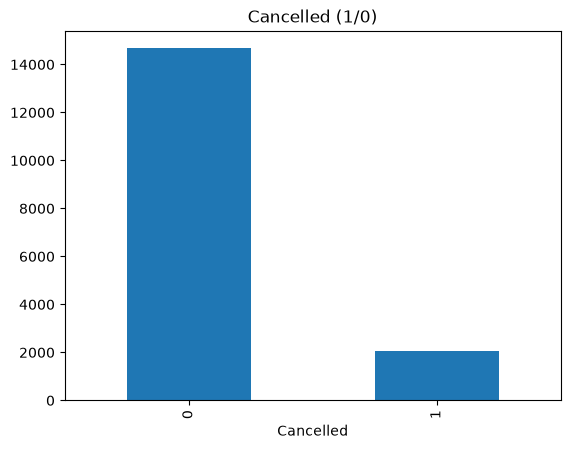

In [16]:
df["Cancelled"].value_counts().plot(kind = "bar")
plt.title("Cancelled (1/0)")
plt.ylabel("")
plt.show()

### Correlation Matrix

In [17]:
numeric_cols = df.select_dtypes(include=["number"])
numeric_cols.corr()

,Salary,CLV,Cancelled,Salary_Missing,tenure,Total Flights,Total Distance,Total Points,Total Redeemed Points,Percentage Redeemed (%)
Salary,1.000000,-0.021676,-0.000472,NaN,0.030632,-0.002465,-0.002965,-0.016860,0.015561,0.011778
CLV,-0.021676,1.000000,0.007817,-0.033468,0.002190,-0.005372,-0.004163,-0.002318,-0.000579,-0.006470
Cancelled,-0.000472,0.007817,1.000000,0.001508,0.009376,-0.451227,-0.435691,-0.377966,-0.271031,-0.089177
Salary_Missing,NaN,-0.033468,0.001508,1.000000,-0.004843,0.007275,0.004289,0.001164,0.010832,0.005592
tenure,0.030632,0.002190,0.009376,-0.004843,1.000000,0.246458,0.239143,0.123084,0.225807,-0.003266
Total Flights,-0.002465,-0.005372,-0.451227,0.007275,0.246458,1.000000,0.967950,0.928546,0.435566,0.006478
Total Distance,-0.002965,-0.004163,-0.435691,0.004289,0.239143,0.967950,1.000000,0.959935,0.422189,-0.013068
Total Points,-0.016860,-0.002318,-0.377966,0.001164,0.123084,0.928546,0.959935,1.000000,0.333918,-0.043373
Total Redeemed Points,0.015561,-0.000579,-0.271031,0.010832,0.225807,0.435566,0.422189,0.333918,1.000000,0.496034
Percentage Redeemed (%),0.011778,-0.006470,-0.089177,0.005592,-0.003266,0.006478,-0.013068,-0.043373,0.496034,1.000000


In [18]:
corr_matrix = numeric_cols.corr().abs()

stacked_corr = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .unstack()
    .dropna()
)

stacked_corr[stacked_corr > 0.7] #highly correlated features

Total Distance  Total Flights     0.967950
Total Points    Total Flights     0.928546
                Total Distance    0.959935
dtype: float64

In [19]:
df.head(1)

,Province,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Cancelled,Salary_Missing,tenure,Total Flights,Total Distance,Total Points,Total Redeemed Points,Percentage Redeemed (%)
0,Alberta,Female,Bachelor,92552,Married,Aurora,7919.2,Standard,0,0,28,46.0,81190.0,81190.0,1513.0,1.9


In [20]:
for col in df.select_dtypes(include=["object", "str"]):
    print(df[col].unique())

<ArrowStringArray>
[             'Alberta',              'Ontario',     'British Columbia',
         'Saskatchewan',               'Quebec',             'Manitoba',
         'Newfoundland',        'New Brunswick',          'Nova Scotia',
 'Prince Edward Island',                'Yukon']
Length: 11, dtype: str
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
<ArrowStringArray>
['Bachelor', 'College', 'Master', 'High School or Below', 'Doctor']
Length: 5, dtype: str
<ArrowStringArray>
['Married', 'Single', 'Divorced']
Length: 3, dtype: str
<ArrowStringArray>
['Aurora', 'Nova', 'Star']
Length: 3, dtype: str
<ArrowStringArray>
['Standard', '2018 Promotion']
Length: 2, dtype: str


In [25]:
X = df.drop(columns = ["Cancelled", "Province", "Gender", "Education", "Marital Status", "Loyalty Card", "Enrollment Type"])
y = df["Cancelled"]

In [26]:
X.head()

,Salary,CLV,Salary_Missing,tenure,Total Flights,Total Distance,Total Points,Total Redeemed Points,Percentage Redeemed (%)
0,92552,7919.20,0,28,46.0,81190.0,81190.0,1513.0,1.9
1,<NA>,2887.74,1,69,51.0,68918.0,68918.0,1195.0,1.7
2,<NA>,2838.07,1,29,47.0,72856.0,72856.0,593.0,0.8
3,63253,4170.57,0,40,22.0,38236.0,38236.0,861.0,2.3
4,91163,6622.05,0,59,37.0,54997.0,54997.0,1007.0,1.8


In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=123)

### GridSearch using param_grid

In [42]:
model = DecisionTreeClassifier()

param_grid = {
    "max_depth" : np.arange(1, 16)
}

grid = GridSearchCV(
    model,
    param_grid,
    cv = 5,
    scoring = "roc_auc",    
    n_jobs=-1,
    return_train_score=True
)

results_dict = {
    "depth": [],
    "mean_train_error": [],
    "mean_cv_error": [],
    "std_cv_error": [],
    "std_train_error": [],
}

for depth in param_grid["max_depth"]:
    model = DecisionTreeClassifier(max_depth=depth)
    scores = cross_validate(model, X_train, y_train, cv=10, return_train_score=True)
    results_dict["depth"].append(depth)
    results_dict["mean_cv_error"].append(1 - np.mean(scores["test_score"]))
    results_dict["mean_train_error"].append(1 - np.mean(scores["train_score"]))
    results_dict["std_cv_error"].append(scores["test_score"].std())
    results_dict["std_train_error"].append(scores["train_score"].std())

results_df = pd.DataFrame(results_dict)
results_df = results_df.set_index("depth")

In [47]:
grid.fit(X_train, y_train)

{'max_depth': np.int64(5)}

In [51]:
grid.best_params_

{'max_depth': np.int64(5)}

In [36]:
results_df

,mean_train_error,mean_cv_error,std_cv_error,std_train_error
depth,,,,
1,0.124206,0.124206,0.000337,0.000037
2,0.058406,0.059899,0.006453,0.000755
3,0.044539,0.046082,0.004940,0.000657
4,0.044489,0.046232,0.004808,0.000654
5,0.042149,0.045709,0.005223,0.000589
6,0.039269,0.046456,0.004753,0.000703
7,0.036008,0.048174,0.005899,0.000853
8,0.032606,0.050041,0.005127,0.001003
9,0.029004,0.052356,0.005530,0.001146


In [41]:
best_depth = results_df["mean_cv_error"].idxmin()
min_cv_error = results_df.loc[:, ["mean_cv_error"]].min()
print(best_depth)
print(min_cv_error)

5
mean_cv_error    0.045709
dtype: float64


In [55]:
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [57]:
y_pred = model.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0], shape=(3348,), dtype=int32)

In [59]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(3348,), dtype=int32)

In [63]:
accuracy_score(y_test, y_pred)

0.9566905615292712

## Random Forest